<a href="https://colab.research.google.com/github/Amulya-Rao-mj/ML2_lab--Amulya-Rao-M-J--4NI23CI013/blob/main/Candidation_Elimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

PREPARED DATASET
    Genre AgeCategory IncomeCategory SpendingCategory HighSpender
0    Male       Young            Low              Low          No
1    Male       Young            Low             High         Yes
2  Female       Young            Low              Low          No
3  Female       Young            Low             High         Yes
4  Female       Adult            Low           Medium          No
5  Female       Young            Low             High         

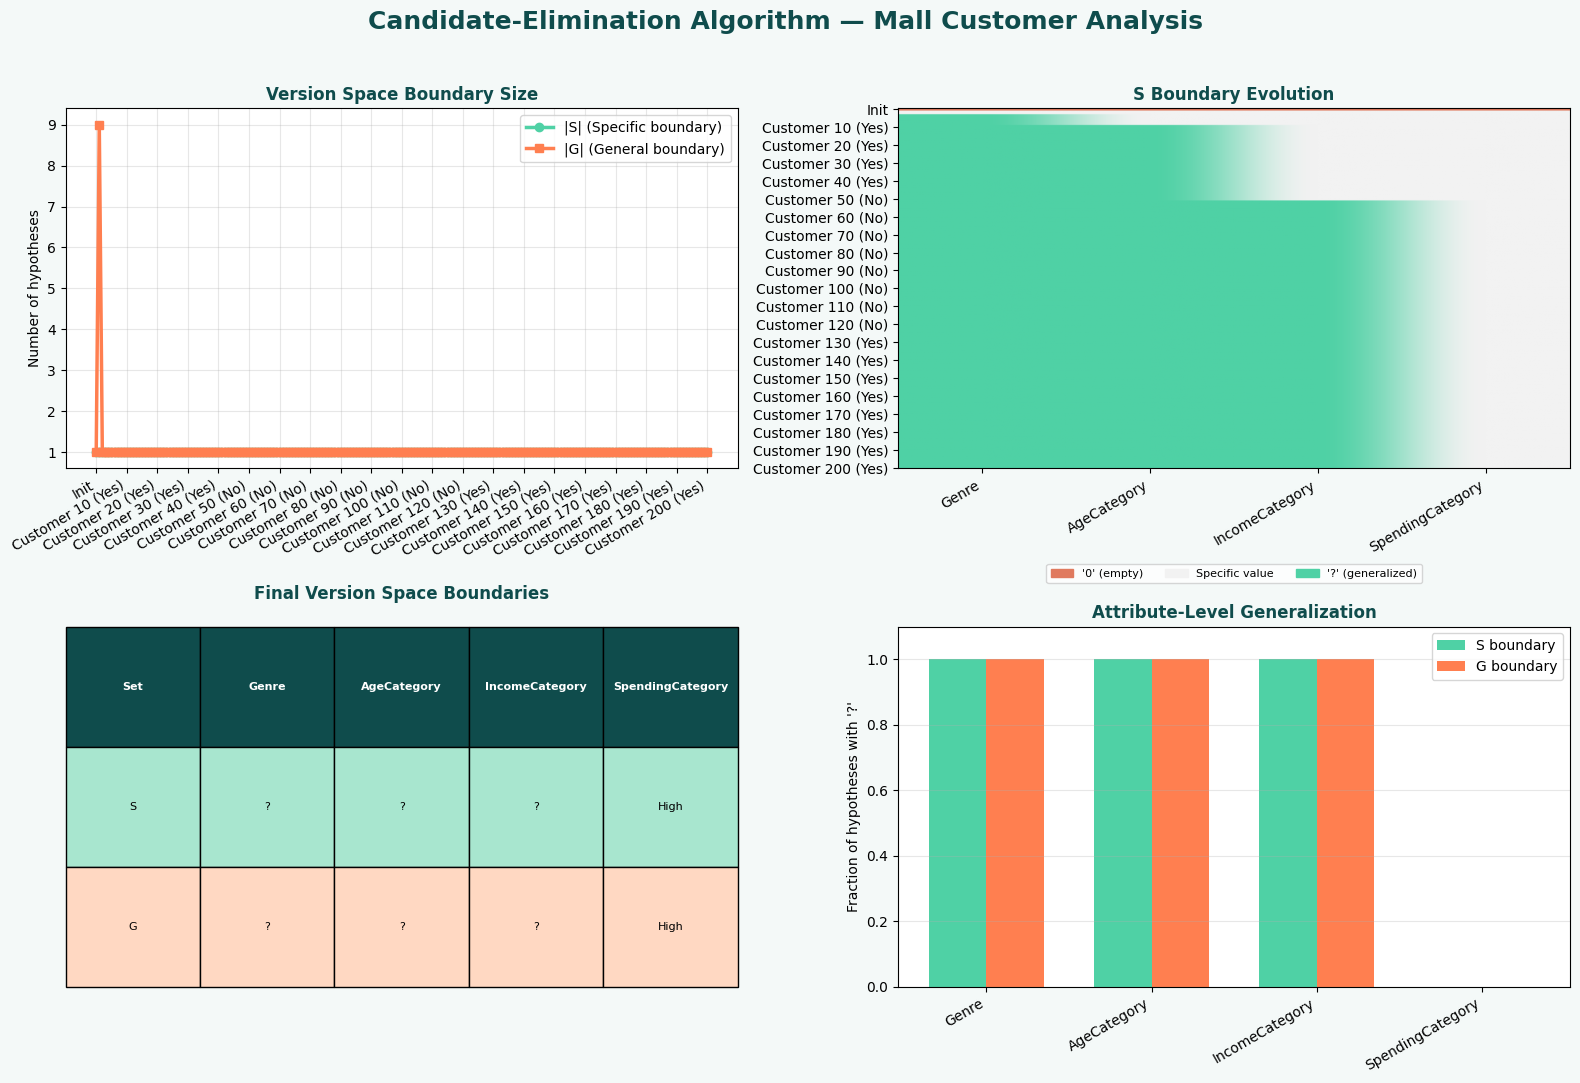


Saved visualization to mall_customer_candidate_elimination.png


In [2]:
"""
Candidate-Elimination Algorithm
Dataset: Mall Customers

Target:
HighSpender = Yes if Spending Score >= 60
HighSpender = No otherwise

Numerical attributes are converted into categorical ranges
so that Candidate-Elimination can be applied.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap


# ---------------------------------------------------------
# 1. LOAD MALL CUSTOMER DATASET
# ---------------------------------------------------------

# Change this to your CSV file name/path
df = pd.read_csv("Mall_Customers.csv")

print("Dataset:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())


# ---------------------------------------------------------
# 2. PREPARE DATA
# ---------------------------------------------------------

# Convert column names if necessary
df = df.rename(columns={
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})


# ---------------------------------------------------------
# CREATE CATEGORICAL ATTRIBUTES
# ---------------------------------------------------------

# Age categories
def age_category(age):
    if age < 25:
        return 'Young'
    elif age < 40:
        return 'Adult'
    elif age < 60:
        return 'Middle'
    else:
        return 'Senior'


# Annual income categories
def income_category(income):
    if income < 40:
        return 'Low'
    elif income < 70:
        return 'Medium'
    elif income < 100:
        return 'High'
    else:
        return 'VeryHigh'


# Spending score categories
def spending_category(score):
    if score < 40:
        return 'Low'
    elif score < 60:
        return 'Medium'
    else:
        return 'High'


df['AgeCategory'] = df['Age'].apply(age_category)
df['IncomeCategory'] = df['AnnualIncome'].apply(income_category)
df['SpendingCategory'] = df['SpendingScore'].apply(spending_category)


# ---------------------------------------------------------
# CREATE TARGET
# ---------------------------------------------------------

# High spender = Spending Score >= 60

df['HighSpender'] = np.where(
    df['SpendingScore'] >= 60,
    'Yes',
    'No'
)


# ---------------------------------------------------------
# ATTRIBUTES USED FOR CANDIDATE-ELIMINATION
# ---------------------------------------------------------

attributes = [
    'Genre',
    'AgeCategory',
    'IncomeCategory',
    'SpendingCategory'
]


data = df[attributes + ['HighSpender']].values.tolist()


X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)


print("\n====================================")
print("PREPARED DATASET")
print("====================================")

print(df[attributes + ['HighSpender']].head(10))

print("\nTarget distribution:")
print(df['HighSpender'].value_counts())


# ---------------------------------------------------------
# 3. HELPER FUNCTIONS
# ---------------------------------------------------------

def more_general(h1, h2):
    """
    Return True if h1 is more general than or equal to h2.
    """

    for x, y_ in zip(h1, h2):

        if x == '?':
            continue

        if x == '0':
            return False

        if x != y_ and y_ != '0':
            return False

    return True


def consistent(h, instance):
    """
    Check whether hypothesis h matches instance.
    """

    for hx, ix in zip(h, instance):

        if hx == '?':
            continue

        if hx != ix:
            return False

    return True


def min_generalizations(h, instance):
    """
    Return minimal generalizations of h
    that match the positive instance.
    """

    new_h = list(h)

    for i in range(len(h)):

        if h[i] == '0':
            new_h[i] = instance[i]

        elif h[i] != instance[i]:
            new_h[i] = '?'

    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """
    Return minimal specializations of h
    that do NOT match the negative instance.
    """

    results = []

    for i in range(len(h)):

        if h[i] == '?':

            for val in domains[i]:

                if val != instance[i]:

                    new_h = list(h)
                    new_h[i] = val

                    results.append(tuple(new_h))

        elif h[i] != '0':

            new_h = list(h)
            new_h[i] = '0'

            results.append(tuple(new_h))

    return results


def remove_more_general(hyps):
    """
    Remove hypotheses that are more general
    than another hypothesis.
    """

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h2, h)
            for h2 in hyps
        )
    ]


def remove_less_general(hyps):
    """
    Remove hypotheses that are less general
    than another hypothesis.
    """

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h, h2)
            for h2 in hyps
        )
    ]


# ---------------------------------------------------------
# 4. CANDIDATE-ELIMINATION ALGORITHM
# ---------------------------------------------------------

def candidate_elimination(X, y, attributes):

    domains = [
        sorted(set(row[i] for row in X))
        for i in range(len(attributes))
    ]

    # Most specific hypothesis
    S = [
        tuple(['0'] * n_attributes)
    ]

    # Most general hypothesis
    G = [
        tuple(['?'] * n_attributes)
    ]

    # History for visualization
    history = {

        'S_sizes': [len(S)],

        'G_sizes': [len(G)],

        'S_sets': [list(S)],

        'G_sets': [list(G)],

        'labels': ['Init']
    }


    for idx, (instance, label) in enumerate(zip(X, y)):

        instance = tuple(instance)


        # -------------------------------------------------
        # POSITIVE EXAMPLE
        # -------------------------------------------------

        if label == 'Yes':

            G = [
                g for g in G
                if consistent(g, instance)
            ]

            new_S = []

            for s in S:

                if consistent(s, instance):

                    new_S.append(s)

                else:

                    generalizations = min_generalizations(
                        s,
                        instance
                    )

                    for h in generalizations:

                        if any(
                            more_general(g, h)
                            for g in G
                        ):

                            new_S.append(h)


            S = remove_more_general(
                list(set(new_S))
            )


        # -------------------------------------------------
        # NEGATIVE EXAMPLE
        # -------------------------------------------------

        else:

            S = [
                s for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            for g in G:

                if not consistent(g, instance):

                    new_G.append(g)

                else:

                    specializations = min_specializations(
                        g,
                        domains,
                        instance
                    )

                    for h in specializations:

                        if any(
                            more_general(h, s)
                            for s in S
                        ):

                            new_G.append(h)


            G = remove_less_general(
                list(set(new_G))
            )


        # -------------------------------------------------
        # SAVE HISTORY
        # -------------------------------------------------

        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))

        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))

        history['labels'].append(
            f'Customer {idx + 1} ({label})'
        )


        # -------------------------------------------------
        # PRINT CURRENT BOUNDARIES
        # -------------------------------------------------

        print(
            f"\n--- After Customer {idx + 1} "
            f"({instance} -> {label}) ---"
        )

        print("S (specific boundary):")

        for s in S:
            print("  ", s)

        print("G (general boundary):")

        for g in G:
            print("  ", g)


    return S, G, history


# ---------------------------------------------------------
# 5. RUN CANDIDATE-ELIMINATION
# ---------------------------------------------------------

S_final, G_final, history = candidate_elimination(
    X,
    y,
    attributes
)


# ---------------------------------------------------------
# 6. FINAL RESULTS
# ---------------------------------------------------------

print("\n============================")
print("FINAL SPECIFIC BOUNDARY (S):")
print("============================")

for s in S_final:
    print("  ", s)


print("\n============================")
print("FINAL GENERAL BOUNDARY (G):")
print("============================")

for g in G_final:
    print("  ", g)


# ---------------------------------------------------------
# 7. ANALYSIS VISUALIZATIONS
# ---------------------------------------------------------

COL_TEAL = '#0f4c4c'
COL_MINT = '#4fd1a5'
COL_LIGHT = '#a8e6cf'
COL_ACCENT = '#ff7f50'
COL_BG = '#f4f9f8'


def specificity_score(h):

    """
    Encode hypothesis into numeric values.

    -1 = empty
     0 = specific value
     1 = ?
    """

    return [
        (
            -1 if v == '0'
            else 1 if v == '?'
            else 0
        )
        for v in h
    ]


# ---------------------------------------------------------
# CREATE DASHBOARD
# ---------------------------------------------------------

fig = plt.figure(
    figsize=(16, 11),
    facecolor=COL_BG
)

fig.suptitle(
    'Candidate-Elimination Algorithm — Mall Customer Analysis',
    fontsize=18,
    fontweight='bold',
    color=COL_TEAL,
    y=0.98
)


# ---------------------------------------------------------
# PLOT 1
# Boundary size trend
# ---------------------------------------------------------

ax1 = plt.subplot(2, 2, 1)

steps = range(len(history['S_sizes']))

ax1.plot(
    steps,
    history['S_sizes'],
    marker='o',
    color=COL_MINT,
    linewidth=2.5,
    label='|S| (Specific boundary)',
    markersize=6
)

ax1.plot(
    steps,
    history['G_sizes'],
    marker='s',
    color=COL_ACCENT,
    linewidth=2.5,
    label='|G| (General boundary)',
    markersize=6
)

ax1.set_xticks(steps)

# Avoid overcrowding when there are many customers
if len(steps) > 20:

    tick_positions = list(range(0, len(steps), 10))

    ax1.set_xticks(tick_positions)

    ax1.set_xticklabels(
        [
            history['labels'][i]
            for i in tick_positions
        ],
        rotation=30,
        ha='right'
    )

else:

    ax1.set_xticklabels(
        history['labels'],
        rotation=30,
        ha='right'
    )


ax1.set_ylabel('Number of hypotheses')

ax1.set_title(
    'Version Space Boundary Size',
    color=COL_TEAL,
    fontweight='bold'
)

ax1.legend()

ax1.grid(alpha=0.3)

ax1.set_facecolor('white')


# ---------------------------------------------------------
# PLOT 2
# S Boundary Evolution
# ---------------------------------------------------------

ax2 = plt.subplot(2, 2, 2)

s_track = []

for s_set in history['S_sets']:

    h = (
        s_set[0]
        if s_set
        else tuple(['0'] * n_attributes)
    )

    s_track.append(
        specificity_score(h)
    )


s_matrix = np.array(s_track)


cmap = ListedColormap([
    '#e07a5f',
    '#f2f2f2',
    COL_MINT
])


im = ax2.imshow(
    s_matrix,
    aspect='auto',
    cmap=cmap,
    vmin=-1,
    vmax=1
)


ax2.set_xticks(
    range(n_attributes)
)

ax2.set_xticklabels(
    attributes,
    rotation=30,
    ha='right'
)


# Only show selected customer labels
if len(history['labels']) > 20:

    tick_positions = list(
        range(0, len(history['labels']), 10)
    )

    ax2.set_yticks(tick_positions)

    ax2.set_yticklabels(
        [
            history['labels'][i]
            for i in tick_positions
        ]
    )

else:

    ax2.set_yticks(
        range(len(history['labels']))
    )

    ax2.set_yticklabels(
        history['labels']
    )


ax2.set_title(
    'S Boundary Evolution',
    color=COL_TEAL,
    fontweight='bold'
)


patches = [

    mpatches.Patch(
        color='#e07a5f',
        label="'0' (empty)"
    ),

    mpatches.Patch(
        color='#f2f2f2',
        label='Specific value'
    ),

    mpatches.Patch(
        color=COL_MINT,
        label="'?' (generalized)"
    )
]


ax2.legend(
    handles=patches,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=8
)


# ---------------------------------------------------------
# PLOT 3
# Final S vs G
# ---------------------------------------------------------

ax3 = plt.subplot(2, 2, 3)

ax3.axis('off')

ax3.set_title(
    'Final Version Space Boundaries',
    color=COL_TEAL,
    fontweight='bold',
    pad=20
)


table_data = []

row_colors = []


for s in S_final:

    table_data.append(
        ['S'] + list(s)
    )

    row_colors.append(
        COL_LIGHT
    )


for g in G_final:

    table_data.append(
        ['G'] + list(g)
    )

    row_colors.append(
        '#ffd8c2'
    )


col_labels = [
    'Set'
] + attributes


if table_data:

    tbl = ax3.table(
        cellText=table_data,
        colLabels=col_labels,
        loc='center',
        cellLoc='center',
        bbox=[0, 0, 1, 1]
    )

    tbl.auto_set_font_size(False)

    tbl.set_fontsize(8)


    for i, color in enumerate(row_colors):

        for j in range(len(col_labels)):

            tbl[
                (i + 1, j)
            ].set_facecolor(color)


    for j in range(len(col_labels)):

        tbl[
            (0, j)
        ].set_facecolor(COL_TEAL)

        tbl[
            (0, j)
        ].set_text_props(
            color='white',
            fontweight='bold'
        )


# ---------------------------------------------------------
# PLOT 4
# Attribute-Level Generality
# ---------------------------------------------------------

ax4 = plt.subplot(2, 2, 4)


if S_final:

    s_generality = np.mean(
        [
            [
                1 if v == '?' else 0
                for v in s
            ]
            for s in S_final
        ],
        axis=0
    )

else:

    s_generality = np.zeros(
        n_attributes
    )


if G_final:

    g_generality = np.mean(
        [
            [
                1 if v == '?' else 0
                for v in g
            ]
            for g in G_final
        ],
        axis=0
    )

else:

    g_generality = np.zeros(
        n_attributes
    )


x_pos = np.arange(
    n_attributes
)

width = 0.35


ax4.bar(
    x_pos - width / 2,
    s_generality,
    width,
    label='S boundary',
    color=COL_MINT
)


ax4.bar(
    x_pos + width / 2,
    g_generality,
    width,
    label='G boundary',
    color=COL_ACCENT
)


ax4.set_xticks(x_pos)

ax4.set_xticklabels(
    attributes,
    rotation=30,
    ha='right'
)


ax4.set_ylabel(
    "Fraction of hypotheses with '?'"
)


ax4.set_title(
    'Attribute-Level Generalization',
    color=COL_TEAL,
    fontweight='bold'
)


ax4.legend()

ax4.grid(
    alpha=0.3,
    axis='y'
)

ax4.set_ylim(
    0,
    1.1
)

ax4.set_facecolor('white')


# ---------------------------------------------------------
# SAVE AND DISPLAY
# ---------------------------------------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    'mall_customer_candidate_elimination.png',
    dpi=150,
    facecolor=COL_BG
)

plt.show()


print(
    "\nSaved visualization to "
    "mall_customer_candidate_elimination.png"
)